In [1]:
import torch
from matplotlib import pyplot as plt
from whar_datasets.adapters.pytorch import PytorchAdapter
from whar_datasets.support.getter import WHARDatasetID, get_whar_cfg
from flow_matching.latent.training_cae import CAETrainer, detransform, transform
from flow_matching.whar.stft import plot_spectrogram_grid, decompress_stft

# from flow_matching.whar.models.autoencoder import (
#     SpectrogramCAE,
#     SpectrogramAEC,
#     SpectrogramAE,
# )

from flow_matching.whar.models.autoencoder_8 import (
    SpectrogramCAE,
    SpectrogramAEC,
    SpectrogramAE,
)

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
cfg = get_whar_cfg(WHARDatasetID.UCI_HAR)
dataset = PytorchAdapter(cfg)

train_loader, val_loader, test_loader = dataset.get_dataloaders(
    train_batch_size=32, scv_group_index=0
)

num_classes = len(dataset.get_class_weights(train_loader))

Creating config hash...
Checking download...
Download exists.
Checking sessions...
Sessions exist.
Validating common format...
[########################################] | 100% Completed | 985.06 ms
Common format validated.
Checking windowing...
Loading config hash...
Windowing exists.
subject_ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
activity_ids: [0 1 2 3 4 5]
train: 7201 | val: 801 | test: 1497
Postprocessing...


Loading windows: 100%|██████████| 9499/9499 [00:06<00:00, 1396.08it/s]


Getting normalization parameters...
Loading config hash...
Creating normalization parameters hash...
Loading normalization parameters hash...


Loading samples: 100%|██████████| 9499/9499 [00:02<00:00, 3884.46it/s]


In [4]:
spect_c = 18
latent_c = 24

ae = SpectrogramAEC(spect_c=spect_c, latent_c=latent_c)
# ae = SpectrogramAE(spect_c=spect_c, latent_c=latent_c)

trainer = CAETrainer(
    model=ae,
    train_loader=train_loader,
    val_loader=val_loader,
    eta=(1 / num_classes),
    null_class=num_classes,
    track=True,
)

In [6]:
trainer.train(num_epochs=30, device=device, lr=1e-3)

Training model with size: 1.936 MiB


  0%|          | 0/1 [00:00<?, ?it/s]/Users/maxburzer/flow-matching/src/flow_matching/whar/stft.py:33: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::istft. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:84.)
  waveform = torch.istft(
100%|██████████| 1/1 [00:01<00:00,  1.07s/it]


['loss: 0.075', 'mse: 0.023', 'log_mag_phase: 2.674', 'spect_conv: 0.683', 'time_mse: 284.895', 'time_mae: 9875.570']


100%|██████████| 1/1 [00:00<00:00,  1.08it/s]


['loss: 0.074', 'mse: 0.022', 'log_mag_phase: 2.823', 'spect_conv: 0.688', 'time_mse: 280.867', 'time_mae: 9720.525']


...

['loss: 0.054', 'mse: 0.003', 'log_mag_phase: 1.192', 'spect_conv: 0.215', 'time_mse: 18.818', 'time_mae: 2390.463']


100%|██████████| 1/1 [00:00<00:00,  1.07it/s]


['loss: 0.055', 'mse: 0.003', 'log_mag_phase: 1.210', 'spect_conv: 0.214', 'time_mse: 18.631', 'time_mae: 2395.367']


100%|██████████| 1/1 [00:00<00:00,  1.07it/s]

['loss: 0.054', 'mse: 0.003', 'log_mag_phase: 1.190', 'spect_conv: 0.210', 'time_mse: 17.809', 'time_mae: 2335.487']


In [7]:
torch.save(ae.state_dict(), f"models/aec_{latent_c}_8.pt")

In [ ]:
ae.load_state_dict(torch.load(f"models/cae_{latent_c}_new.pt"))

<All keys matched successfully>

tensor(-0.9450, device='mps:0', grad_fn=<MinBackward1>) tensor(0.9403, device='mps:0', grad_fn=<MaxBackward1>)


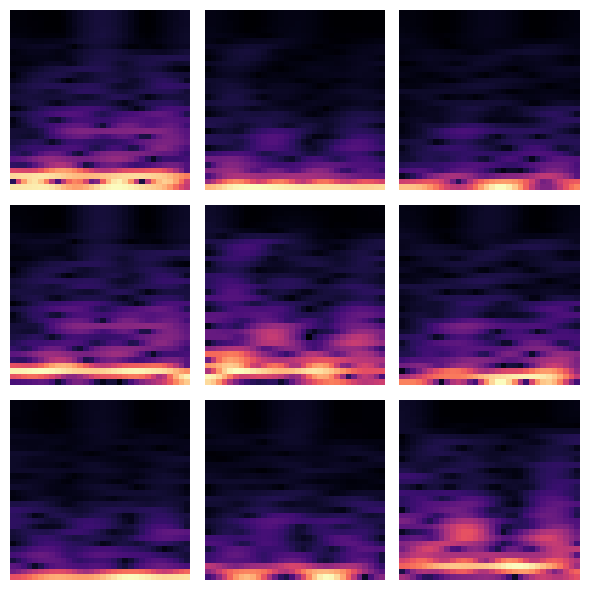

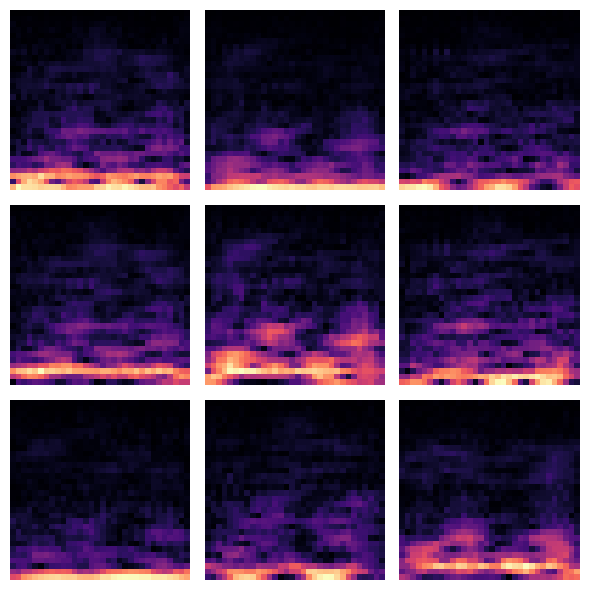

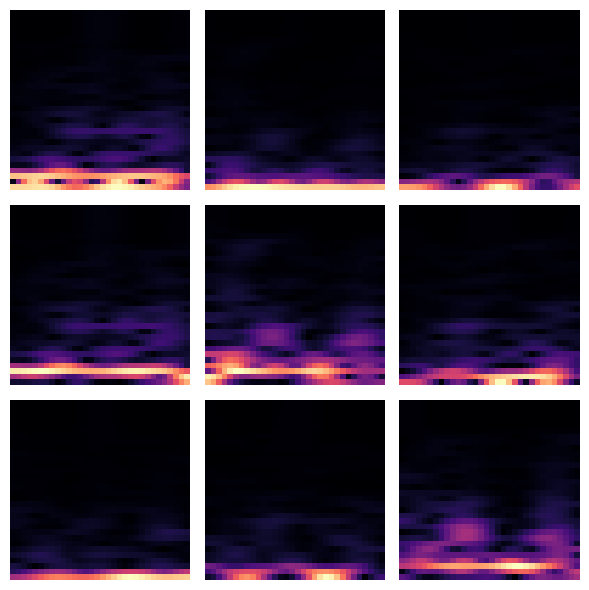

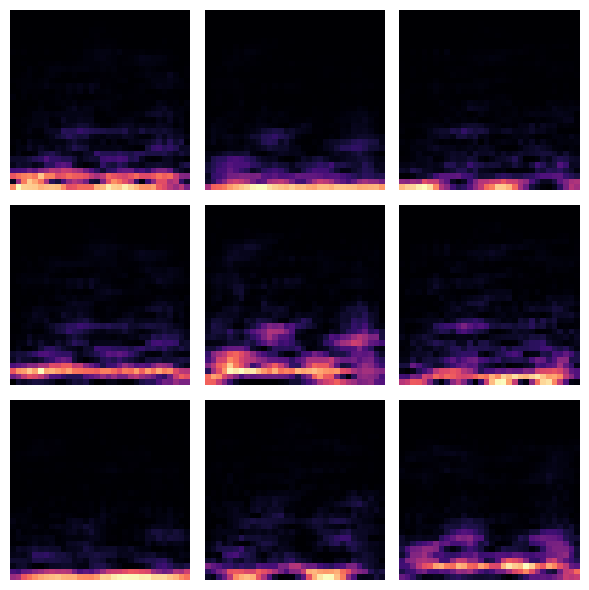

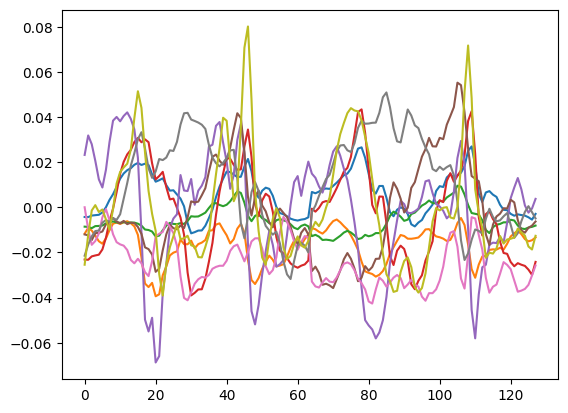

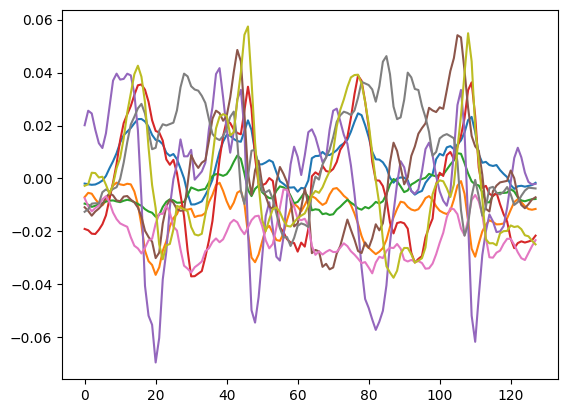

In [10]:
x, y = next(iter(train_loader))
recon, z = ae(x.to(device), y.to(device))

print(recon.min(), recon.max())

x = x[0].detach().cpu()
recon = recon[0].detach().cpu()

C, H, W = recon.shape

x_reshaped = x.reshape(C // 2, 2, H, W)
recon_reshaped = recon.reshape(C // 2, 2, H, W)

plot_spectrogram_grid(x_reshaped)
plot_spectrogram_grid(recon_reshaped)

plot_spectrogram_grid(decompress_stft(x_reshaped))
plot_spectrogram_grid(decompress_stft(recon_reshaped))

plt.plot(detransform(x))
plt.show()

plt.plot(detransform(recon))
plt.show()